In [ ]:
##### Database ####
import lancedb

uri = "ex_lancedb"
db = lancedb.connect(uri)
import pandas as pd

# df = pd.read_csv("uk_attractions_main.csv", encoding="utf-8",sep=";")
# vectors_df = pd.read_pickle("uk_attractions_vectors.pkl")

# df2 = df.drop(columns="image").join(vectors_df.drop(columns=['name', 'image_path']), on="id")
# df2 = df2.fillna("")

# table = db.create_table("attractions", data=df2.to_dict(orient='records'), mode='overwrite')
# table.create_scalar_index("id")
# table.create_scalar_index("county", index_type="BITMAP")
# table.create_scalar_index("region", index_type="BITMAP")
# table.create_scalar_index("country", index_type="BITMAP")

In [ ]:
import numpy as np
import pandas as pd

#['animals', 'architecture', 'entertainment', 'history_culture', 'natural', 'sea','shopping','sports', 'topspot']
mhe = np.array([0,1,0,0,1,0,0,1,1])

example_user = np.concatenate([mhe, np.zeros(768)])
table = db.open_table("attractions")

eg_set = set()
eg_set.add("Q116193756")
eg_set.add("Q4979595")

id_str = ", ".join([f"'{i}'" for i in eg_set])
visited_filter = f"AND id NOT IN ({id_str})"

visited_filter

filter = "country == 'Scotland'" + visited_filter



results = (
    table.search(query=example_user, vector_column_name="finalVector")
    .distance_type("cosine")
    .where(filter)
    .limit(5)
    .to_pandas()    
)

results
# results = results.drop(0).reset_index(drop=True)
# # results['sim_score'] = results["_distance"].apply(lambda distance: 1 - distance)


## Jubilee Pool | Type: architectural structure, park | Cornwall, South West, England
# Summary: Jubilee Pool (Cornish: Poll Jubile) is an Art Deco lido in Penzance, Cornwall. It is Grade II listed, being recognised as the finest surviving example of its type with the exception of Saltdean Lido. With a capacity of 5 million litres and 600 swimmers and measuring 300 feet long and 160 feet wide, it is the UK's largest seawater pool.
# Image:


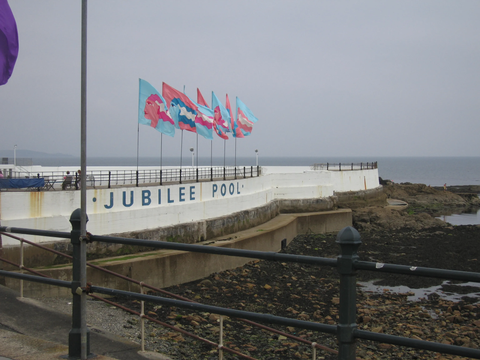

In [1]:
### TEST WITH VISUAL: FRONT-END ####
from app import User
from IPython.display import clear_output
from PIL import Image
import numpy as np
import pandas as pd

#['animals', 'architecture', 'entertainment', 'history_culture', 'natural', 'sea','shopping','sports', 'topspot']
mhe = np.array([0,1,0,0,1,0,0,1,1])

def displayImgFromPaths(pathStr):
    paths = pathStr.split(",")
    for path in paths:
        image = Image.open(fp=path.strip())
        image.thumbnail((640,360), Image.Resampling.LANCZOS)
        display(image)


def displayFromRec(recommended_items: pd.DataFrame, user: User):
    for _, row in enumerate(recommended_items.itertuples()):
        # if (row.id in self.history): continue
        print(f"## {row.name} | Type: {row.typeLabel} | {row.county}, {row.region}, {row.country}\n# Summary: {row.summary}\n# Image:")
        # print(f"## {row.name} | Type: {row.typeLabel} | Similarity score: {similarity_scores[i]}")
        displayImgFromPaths(row.image_path)
        print("\n")
        while True:
            userFeedback = input("Do you like this place (y/n): ")
            if userFeedback == "y":
                user.like(row.id)
                break
            elif userFeedback == "n":
                user.dislike(row.id)
                break
            else:
                print("Please type 'y' or 'n'")
        clear_output(wait=True)



test = User(mhe)
recommended_items = test.getRecommendations(geo_filter_type="county", geo_filter_name="Cornwall")
displayFromRec(recommended_items, user=test)

## Dodman Point | Type: cape | Cornwall, South West, England
# Summary: Dodman Point (Cornish: Penn Ardh) near Mevagissey is the highest headland on the south Cornwall coast, measuring 374 feet (114 m). It is also known by its earlier names of the Deadman and Deadman's Point.  It hosts the remains of an Iron Age promontory fort, and at its seaward end is "Parson Martin's Cross" – a large granite cross erected in 1896 to encourage those involved in Christian service, and which aids navigation around the headland. Dodman Point is mentioned in the shanty Spanish Ladies.

To its north-east and in its lee is the small anchorage and sand beach of Gorran Haven.
Below the large stone cross, there is a way down to the bottom of the small cliffs and there is some climbing there on the faces – mainly bouldering as it is rarely scaled so there are no fixed anchor points.
# Image:


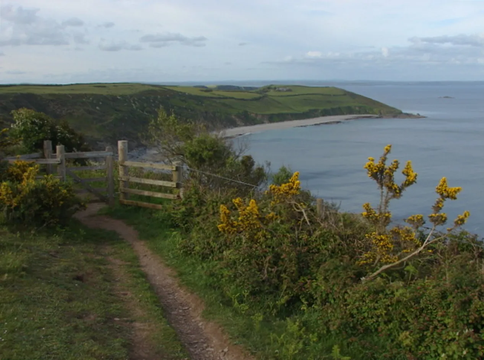

In [2]:
recommended_items = test.getRecommendations(geo_filter_type="county", geo_filter_name="Cornwall")
displayFromRec(recommended_items, user=test)